# Phase 2C-2: validated spatial-anchor coverage and sequence readiness

**Readiness audit only. Phase 2C remains VALIDATED PARTIALLY — NOT LOCKED.**

## 1. Why test sequence readiness?
The full provider event stream and the validated spatial anchors are different populations. Unsupported events remain football context; they do not supply normalized spatial observations. This audit measures empirical support without constructing the analytical sequence dataset, choosing an eligibility threshold, defining dangerous outcomes or interpreting tactics.

Run `.venv/Scripts/python.exe scripts/sequence_readiness.py` from the repository root first. This notebook reads derived diagnostics offline; reusable transformations live in `leverkusen.sequences.readiness`.


In [1]:
from pathlib import Path
import html
import pandas as pd
from IPython.display import HTML, Image, display

root = Path.cwd()
if not (root / "config/project.yaml").exists():
    root = root.parent
assert (root / "config/project.yaml").exists(), "Open from the repository or notebooks directory"
diagnostics = root / "outputs/diagnostics"
revision = "533862946a73608c134d18b78226b6371ce7173c"

def read(name):
    table = pd.read_csv(diagnostics / f"phase2c2_{name}.csv")
    assert "statsbomb_revision" in table
    assert table.statsbomb_revision.eq(revision).all(), "Stale source revision; rerun audit"
    return table.drop(columns="statsbomb_revision")

run = read("run_summary")
p = read("possession_anchor_coverage")
gaps = read("anchor_gap_summary")
assert tuple(run.iloc[0][["all_events", "all_linked_frames", "all_validated_frames", "all_unsupported_frames"]]) == (137765, 118581, 72596, 45985)
assert len(p) == run.leverkusen_possessions.iloc[0]
assert p.total_event_count.sum() == run.leverkusen_possession_events.iloc[0]
assert p.validated_spatial_anchor_count.sum() == run.leverkusen_validated_anchors.iloc[0]
assert len(gaps) == (p.validated_spatial_anchor_count - 1).clip(lower=0).sum()
assert not p[["match_id", "period", "possession_id", "possession_team_id"]].duplicated().any()
display(run.T)


,0
matches,34
all_events,137765
all_linked_frames,118581
all_validated_frames,72596
all_unsupported_frames,45985
leverkusen_possessions,2888
leverkusen_possession_events,86025
leverkusen_linked_frames,74647
leverkusen_validated_anchors,46143
consecutive_anchor_intervals,43431


## 2. Leverkusen possession inventory
Group by match, period, provider possession ID and possession-team ID 904, retaining both teams' events. Period-local provider timestamps include stoppage time. Duration is last event start minus first event start; it is not ball-in-play duration or the end of the last action. No gap crosses periods. Administrative events remain in the denominator.


In [2]:
display(read("sequence_readiness_summary"))
display(p.head(10))
display(read("duration_coverage"))


,metric,value
0,total_leverkusen_possessions,2888.000000
1,total_full_stream_events,86025.000000
2,total_validated_anchor_states,46143.000000
3,median_events_per_possession,20.000000
4,median_360_frames_per_possession,17.000000
5,median_validated_anchors_per_possession,10.000000
6,pct_possessions_ge_1_anchors,93.905817
7,pct_possessions_ge_2_anchors,88.538781
8,pct_possessions_ge_3_anchors,84.072022
9,pct_possessions_ge_4_anchors,78.462604


,match_id,period,possession_id,possession_team_id,first_event_index,last_event_index,first_timestamp,last_timestamp,possession_duration_seconds,total_event_count,...,anchor_count_pass,anchor_count_carry,anchor_count_pressure,opponent_anchor_count,has_shot,has_goal,leverkusen_shot_count,opponent_shot_count,ends_in_shot,final_recorded_event_type
0,3895052,1,1,904,1,4,00:00:00.000,00:00:00.000,0.000,4,...,0,0,0,0,False,False,0,0,False,Half Start
1,3895052,1,6,904,96,111,00:01:52.588,00:01:59.403,6.815,16,...,3,4,1,1,True,False,1,0,True,Shot
2,3895052,1,9,904,118,130,00:02:17.739,00:02:26.455,8.716,13,...,4,1,1,1,False,False,0,0,False,Clearance
3,3895052,1,12,904,162,219,00:03:08.800,00:04:08.334,59.534,58,...,15,11,5,5,False,False,0,0,False,Ball Receipt*
4,3895052,1,15,904,256,264,00:04:58.409,00:05:04.498,6.089,9,...,4,1,0,0,False,False,0,0,False,Ball Receipt*
5,3895052,1,17,904,300,385,00:05:39.491,00:06:50.291,70.800,86,...,23,18,6,7,False,False,0,0,False,Ball Receipt*
6,3895052,1,19,904,407,441,00:07:24.168,00:07:51.754,27.586,35,...,6,6,3,2,True,False,1,0,False,Goal Keeper
7,3895052,1,22,904,478,478,00:09:23.561,00:09:23.561,0.000,1,...,0,0,0,0,False,False,0,0,False,Goal Keeper
8,3895052,1,23,904,479,490,00:09:29.172,00:09:39.825,10.653,12,...,1,3,2,2,False,False,0,0,False,Ball Receipt*
9,3895052,1,26,904,551,607,00:10:52.652,00:11:55.228,62.576,57,...,11,12,2,3,False,False,0,0,False,Duel


,duration_bin,possession_count,mean_anchors,median_anchors,pct_ge_1_anchors,pct_ge_2_anchors,pct_ge_3_anchors,pct_ge_4_anchors,pct_ge_5_anchors,pct_ge_6_anchors,pct_ge_8_anchors,pct_ge_10_anchors,median_events
0,"[0,5) seconds",531,1.905838,1.0,69.491525,47.269303,31.450094,19.397363,11.299435,6.214689,1.318267,0.000000,5.0
1,"[5,15) seconds",744,6.346774,6.0,98.655914,95.026882,90.322581,79.301075,68.817204,56.586022,34.677419,16.397849,12.0
2,"[15,30) seconds",648,13.202160,13.0,99.691358,99.228395,98.611111,97.685185,96.141975,93.827160,86.419753,76.080247,25.0
3,"[30,60) seconds",611,25.214403,25.0,99.836334,98.854337,98.690671,97.872340,96.399345,96.235679,95.090016,94.599018,46.0
4,"[60,infinity) seconds",354,46.463277,47.0,99.717514,99.435028,98.022599,96.610169,95.762712,94.915254,92.655367,91.807910,84.0


## 3. Spatial-anchor count distribution
The frame-level Phase 2C gates are unchanged. A core event type alone is insufficient. Candidate state counts and duration bins describe feasibility and select no future research population. An anchor state is a partial observed frame, not a complete 22-player state.


,population,anchor_requirement,possession_count,denominator,percentage
0,all,zero,176,2888,6.094183
1,all,>=1,2712,2888,93.905817
2,all,>=2,2557,2888,88.538781
3,all,>=3,2428,2888,84.072022
4,all,>=4,2266,2888,78.462604
5,all,>=5,2123,2888,73.511080
6,all,>=6,1986,2888,68.767313
7,all,>=8,1734,2888,60.041551
8,all,>=10,1518,2888,52.562327
9,shot_containing,zero,4,571,0.700525


,measure,count,mean,median,p05,p25,p75,p90,p95,maximum
0,anchors_per_possession,2888,15.977493,10.0,0.0,4.0,22.0,38.3,52.0,120.0


,states,capable_possessions,consecutive_tuples,available_anchor_states_in_capable_possessions
0,2,2557,43431,45988
1,3,2428,40874,45730
2,4,2266,38446,45244
3,5,2123,36180,44672
4,6,1986,34057,43987
5,8,1734,30219,42357


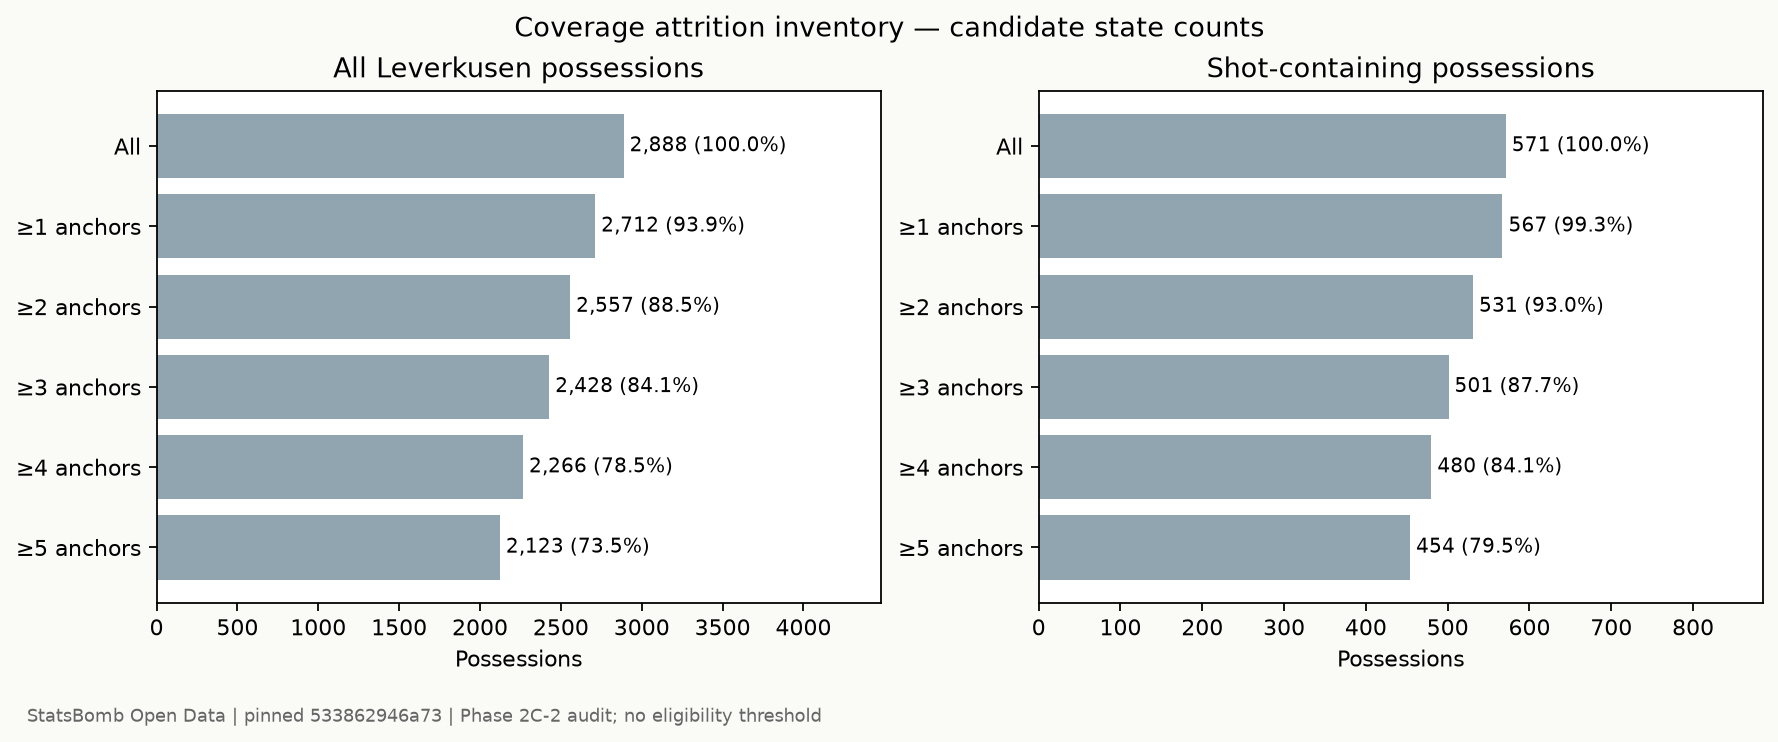

In [3]:
display(read("anchor_count_coverage"))
display(read("distributions").query("measure == 'anchors_per_possession'"))
display(read("sequence_candidates"))
display(Image(filename=str(root / "outputs/figures/phase2c2_sequence_readiness_waterfall.png")))


## 4. Anchor temporal gaps
Intervals are pooled consecutive anchors within the same possession and period. Equal timestamps contribute zero gaps. Overlapping pairs/triples are counted separately; the windows include their endpoints. These are temporal spacings between trusted event-aligned observations, not continuous tracking resolution.


,measure,count,mean,median,p05,p25,p75,p90,p95,maximum
1,anchor_time_gap_seconds,43431,1.525092,1.103,0.098,0.665,1.765,3.214,4.5825,31.708


,seconds,interval_count,denominator,percentage
0,1,19356,43431,44.567245
1,2,34446,43431,79.312012
2,3,38553,43431,88.768391
3,5,41679,43431,95.966015
4,10,43247,43431,99.576339
5,15,43388,43431,99.900992


,unit,states,window_seconds,count
0,consecutive_anchor_tuples,2,3,38553
1,consecutive_anchor_tuples,2,5,41679
2,consecutive_anchor_tuples,2,10,43247
3,consecutive_anchor_tuples,2,15,43388
4,consecutive_anchor_tuples,3,3,25915
5,consecutive_anchor_tuples,3,5,34865
6,consecutive_anchor_tuples,3,10,40152
7,consecutive_anchor_tuples,3,15,40731
8,possessions_with_any_tuple,3,10,2424
9,possessions_with_any_tuple,4,10,2251


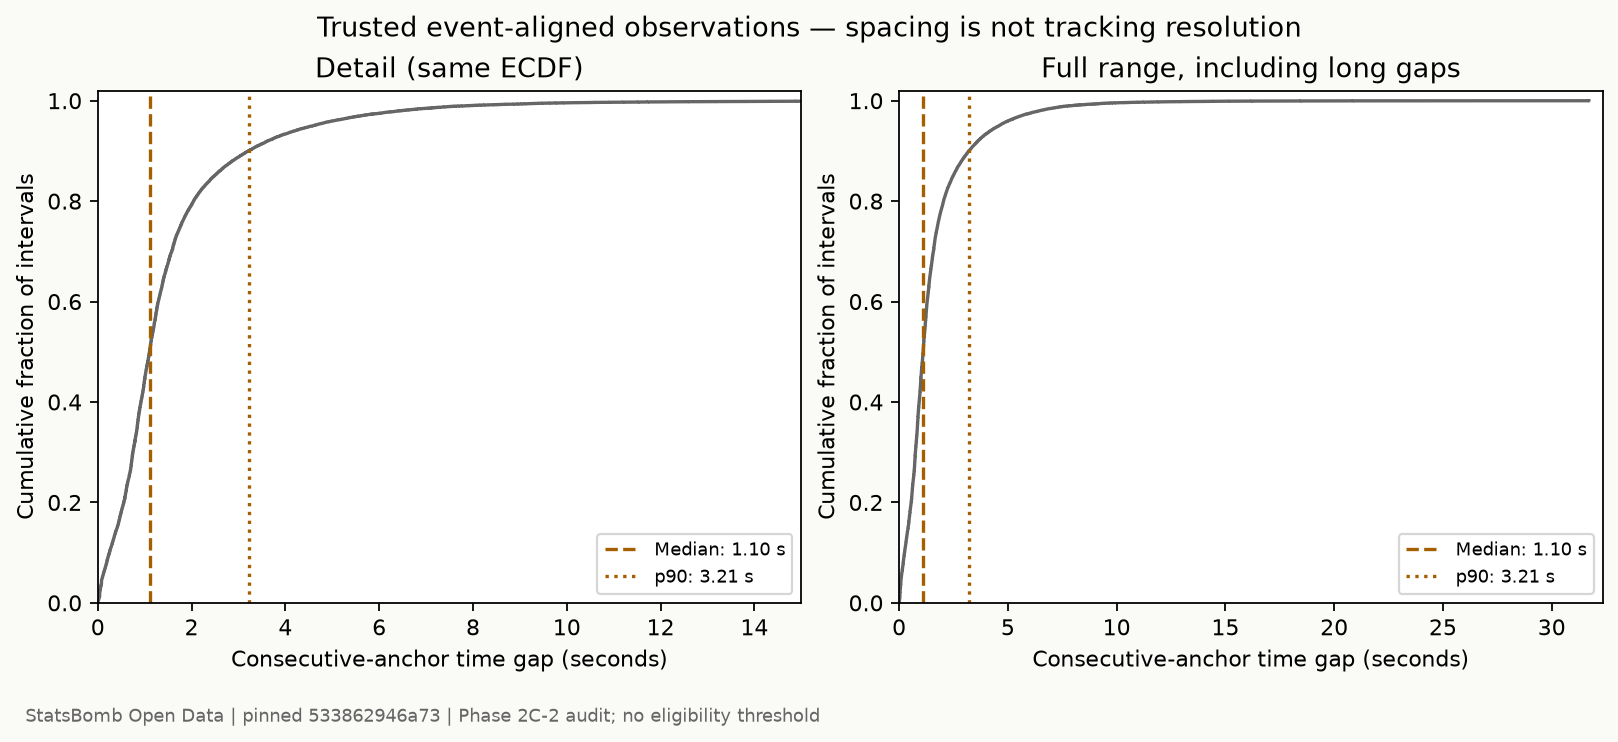

In [4]:
display(read("distributions").query("measure == 'anchor_time_gap_seconds'"))
display(read("gap_thresholds"))
display(read("temporal_windows"))
display(Image(filename=str(root / "outputs/figures/phase2c2_anchor_time_gaps.png")))


## 5. Event gaps
Event-index difference and actual number of intervening rows are separate fields. Every intervening event counts, including unsupported, unlinked and opponent actions. Repeated timestamps and related frames do not establish independent spatial information or ball trajectories.


In [5]:
display(read("distributions").query("measure in ['event_index_gap', 'intervening_events']"))
display(gaps.head(12))
display(read("anchor_type_transitions"))


,measure,count,mean,median,p05,p25,p75,p90,p95,maximum
2,event_index_gap,43431,1.722111,2.0,1.0,1.0,2.0,3.0,4.0,22.0
3,intervening_events,43431,0.722111,1.0,0.0,0.0,1.0,2.0,3.0,21.0


,match_id,period,possession_id,possession_team_id,previous_event_index,next_event_index,event_index_gap,intervening_event_count,elapsed_seconds,previous_anchor_type,next_anchor_type,previous_event_team_id,next_event_team_id
0,3895052,1,6,904,96,98,2,1,0.864,Pass,Pass,904,904
1,3895052,1,6,904,98,100,2,1,0.527,Pass,Carry,904,904
2,3895052,1,6,904,100,101,1,0,0.025,Carry,Pass,904,904
3,3895052,1,6,904,101,103,2,1,0.507,Pass,Carry,904,904
4,3895052,1,6,904,103,105,2,1,0.483,Carry,Pressure,904,904
5,3895052,1,6,904,105,107,2,1,0.093,Pressure,Carry,904,182
6,3895052,1,6,904,107,110,3,2,1.887,Carry,Carry,182,904
7,3895052,1,6,904,110,111,1,0,2.429,Carry,Shot,904,904
8,3895052,1,9,904,118,120,2,1,0.771,Pass,Pass,904,904
9,3895052,1,9,904,120,122,2,1,0.824,Pass,Carry,904,904


,previous_anchor_type,next_anchor_type,interval_count,median_gap_seconds,match_count,percentage_of_intervals
0,Carry,Carry,804,3.3600,34,1.851212
1,Carry,Pass,13538,1.2745,34,31.171283
2,Carry,Pressure,3556,0.7175,34,8.187700
3,Carry,Shot,210,1.3545,34,0.483526
4,Pass,Carry,15119,1.1450,34,34.811540
5,Pass,Pass,2439,1.5050,34,5.615804
6,Pass,Pressure,1976,0.9300,34,4.549746
7,Pass,Shot,187,1.5060,33,0.430568
8,Pressure,Carry,1642,0.2730,34,3.780710
9,Pressure,Pass,3303,0.5050,34,7.605167


## 6. Match coverage
Rates use each match's own Leverkusen-possession denominator. Rank simply identifies comparatively low coverage; it is not an exclusion rule. The frame-validation fraction refers to frames linked to Leverkusen possessions, including opponent events.


,match_id,match_date,opponent,possession_count,mean_anchors,median_anchors,pct_ge_1_anchors,pct_ge_2_anchors,pct_ge_3_anchors,pct_ge_4_anchors,pct_ge_5_anchors,pct_ge_6_anchors,pct_ge_8_anchors,pct_ge_10_anchors,median_anchor_gap_seconds,p90_anchor_gap_seconds,proportion_linked_frames_validated,rank_ge_3_coverage_ascending
0,3895052,2023-08-19,RB Leipzig,86,10.755814,6.0,90.697674,82.558140,74.418605,66.279070,62.790698,55.813953,43.023256,32.558140,1.0960,3.1636,0.620805,2
1,3895060,2023-08-26,Borussia Mönchengladbach,90,16.533333,10.5,98.888889,93.333333,85.555556,78.888889,75.555556,68.888889,57.777778,53.333333,0.9710,3.1194,0.621814,19
2,3895067,2023-09-02,Darmstadt 98,80,19.887500,15.5,93.750000,92.500000,91.250000,88.750000,85.000000,78.750000,73.750000,70.000000,1.1105,3.3265,0.617864,32
3,3895074,2023-09-15,Bayern Munich,85,13.882353,9.0,91.764706,85.882353,77.647059,72.941176,70.588235,67.058824,56.470588,48.235294,1.0770,3.0584,0.619098,5
4,3895086,2023-09-24,FC Heidenheim,88,17.863636,12.0,95.454545,92.045455,89.772727,84.090909,80.681818,78.409091,72.727273,61.363636,1.1385,3.6280,0.613105,31
5,3895095,2023-09-30,FSV Mainz 05,75,15.226667,10.0,94.666667,84.000000,78.666667,74.666667,68.000000,57.333333,53.333333,50.666667,1.1030,3.1030,0.611676,6
6,3895107,2023-10-08,FC Köln,79,19.873418,17.0,91.139241,87.341772,86.075949,79.746835,70.886076,69.620253,67.088608,62.025316,1.0915,2.8789,0.619574,21
7,3895113,2023-10-21,Wolfsburg,89,14.505618,9.0,89.887640,86.516854,80.898876,76.404494,71.910112,68.539326,55.056180,46.067416,1.0510,2.7260,0.624577,8
8,3895121,2023-10-29,Freiburg,86,16.976744,9.0,91.860465,80.232558,72.093023,67.441860,63.953488,62.790698,55.813953,46.511628,1.1430,3.5910,0.606816,1
9,3895134,2023-11-04,Hoffenheim,79,13.734177,7.0,88.607595,87.341772,82.278481,78.481013,72.151899,63.291139,49.367089,43.037975,1.1460,3.5260,0.618586,10


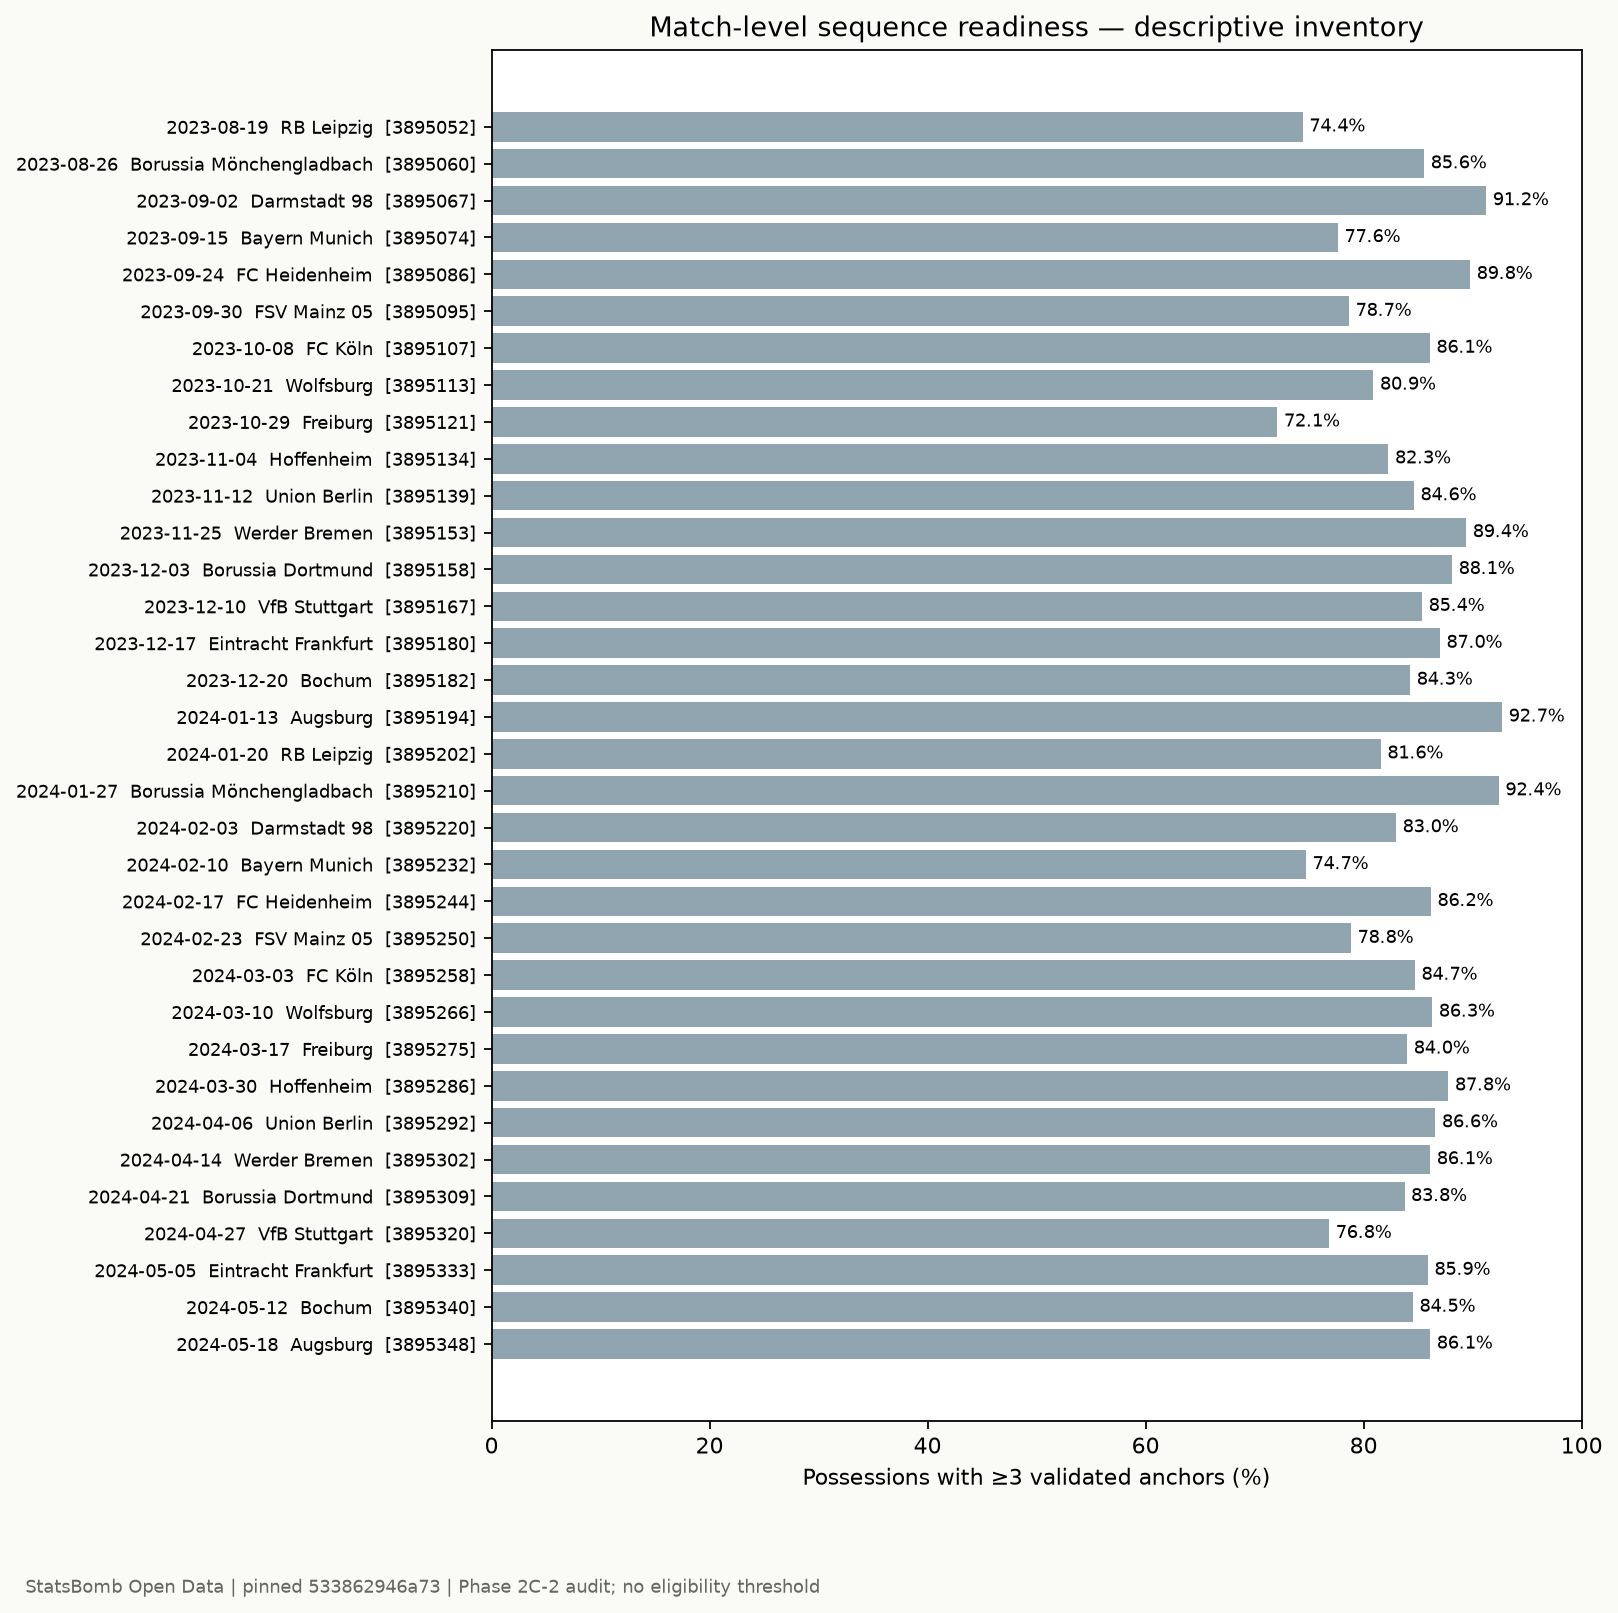

In [6]:
matches = read("match_coverage")
assert len(matches) == 34
with pd.option_context("display.max_rows", 40):
    display(matches)
display(Image(filename=str(root / "outputs/figures/phase2c2_match_coverage.png")))


## 7. Shot-possession coverage
`has_shot` means any provider Shot inside the possession, with own/opponent shot counts kept separate. `has_goal` is a Shot with provider outcome Goal, not an own-goal or scoreboard inventory. `ends_in_shot` uses the literal final recorded event. A final meaningful event is not defined: dropping goalkeeper, stoppage or administrative records would need an additional method. These groups define neither danger nor success.

Box-entry inventory is deferred because universal event-location semantics and entry/completion handling remain unresolved. The provisional zone configuration is not promoted to a permanent entry rule.


In [7]:
display(read("shot_coverage"))
display(p[["leverkusen_shot_count", "opponent_shot_count", "has_shot", "has_goal", "ends_in_shot"]].sum().to_frame("count"))


,population,possession_count,mean_anchors,median_anchors,pct_ge_1_anchors,pct_ge_2_anchors,pct_ge_3_anchors,pct_ge_4_anchors,pct_ge_5_anchors,pct_ge_6_anchors,...,pct_ge_10_anchors,gap_count,gap_mean,gap_median,gap_p05,gap_p25,gap_p75,gap_p90,gap_p95,gap_maximum
0,shot_containing,571,20.416813,14.0,99.299475,92.994746,87.740806,84.063047,79.509632,76.182137,...,60.070053,11091,1.567906,1.133,0.11900,0.701,1.82100,3.3270,4.69950,26.486
1,no_shot,2317,14.883470,10.0,92.576608,87.440656,83.167890,77.082434,72.032801,66.940009,...,50.712128,32340,1.510409,1.091,0.09100,0.649,1.74600,3.1711,4.52600,31.708
2,literal_final_event_shot,42,18.214286,14.0,97.619048,90.476190,88.095238,83.333333,80.952381,78.571429,...,59.523810,724,1.672905,1.197,0.15815,0.724,1.91775,3.4381,4.95505,26.486


,count
leverkusen_shot_count,615
opponent_shot_count,7
has_shot,571
has_goal,88
ends_in_shot,42


## 8. Event-team composition
Possession team is not instantaneous control. Opponent anchors remain included and distinguishable. A validated Pressure frame is a spatial observation; its event location is not automatically a ball position.


In [8]:
display(read("anchor_type_composition"))
display(read("event_team_composition"))


,event_type,anchor_count,percentage_of_anchors,possessions_containing,percentage_of_possessions,match_count
0,Carry,18525,40.146935,2462,85.249307,34
1,Pass,20921,45.339488,2588,89.612188,34
2,Pressure,6109,13.239278,2086,72.229917,34
3,Shot,588,1.274299,541,18.732687,34


,event_team,event_type,anchor_count,percentage_of_all_anchors,percentage_within_event_team,possessions_containing,match_count
0,Leverkusen,All,39297,85.163513,100.000000,2699,34
1,Leverkusen,Carry,17892,38.775112,45.530193,2452,34
2,Leverkusen,Pass,20092,43.542899,51.128585,2586,34
3,Leverkusen,Pressure,732,1.586373,1.862738,545,34
4,Leverkusen,Shot,581,1.259129,1.478484,534,34
5,Opponent,All,6846,14.836487,100.000000,2074,34
6,Opponent,Carry,633,1.371822,9.246275,447,34
7,Opponent,Pass,829,1.796589,12.109261,530,34
8,Opponent,Pressure,5377,11.652905,78.542214,2001,34
9,Opponent,Shot,7,0.015170,0.102249,7,7


## 9. Representative possession timelines
Ten deterministic review examples use lexicographically first distinct keys in documented strata, with the maximum-count possession reserved first. Count/duration/rate quantiles describe selection only. They are not prevalence estimates or analytical eligibility thresholds. Expand each table to see every recorded event in that example; no raw coordinates or full-season event rows are saved.


In [9]:
manifest = read("representative_possessions")
timelines = read("representative_timelines")
display(manifest[["selection_rule", "match_id", "period", "possession_id", "total_event_count", "validated_spatial_anchor_count", "possession_duration_seconds", "has_shot", "opponent_anchor_count"]])
for row in manifest.itertuples(index=False):
    group = timelines[timelines.selection_rule.eq(row.selection_rule)]
    columns = ["elapsed_possession_seconds", "event_type", "event_team", "spatial_status", "semantics_status"]
    title = f"{row.selection_rule}: match {row.match_id}, period {row.period}, possession {row.possession_id}"
    display(HTML(f"<details><summary>{html.escape(title)}</summary>{group[columns].to_html(index=False)}</details>"))


,selection_rule,match_id,period,possession_id,total_event_count,validated_spatial_anchor_count,possession_duration_seconds,has_shot,opponent_anchor_count
0,maximum_anchor_count,3895210,1,15,233,120,173.277,False,21
1,zero_anchors,3895052,1,1,4,0,0.000,False,0
2,one_anchor,3895052,1,75,4,1,0.740,False,0
3,two_anchors,3895052,1,48,8,2,4.602,False,1
4,moderate_anchor_count,3895052,1,6,16,9,6.815,True,1
5,high_anchor_count,3895052,2,120,91,54,95.123,False,7
6,shot_containing,3895052,1,19,35,16,27.586,True,2
7,opponent_anchor,3895052,1,9,13,6,8.716,False,1
8,long_sparse,3895052,1,26,57,25,62.576,False,3
9,short_dense,3895052,1,15,9,5,6.089,False,0


elapsed_possession_seconds,event_type,event_team,spatial_status,semantics_status
0.000,Pass,Leverkusen,validated,validated_core_event_team_scope
1.522,Clearance,Opponent,unsupported,unsupported_event_type
4.380,Clearance,Opponent,unsupported,unsupported_event_type
5.306,Clearance,Opponent,unsupported,unsupported_event_type
6.921,Ball Recovery,Leverkusen,unsupported,unsupported_event_type
6.921,Carry,Leverkusen,validated,validated_core_event_team_scope
9.867,Pass,Leverkusen,no_360_frame,no_360_frame
11.705,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
11.705,Carry,Leverkusen,validated,validated_core_event_team_scope
14.230,Pressure,Opponent,validated,validated_core_event_team_scope


elapsed_possession_seconds,event_type,event_team,spatial_status,semantics_status
0.0,Starting XI,Leverkusen,no_360_frame,no_360_frame
0.0,Starting XI,Opponent,no_360_frame,no_360_frame
0.0,Half Start,Leverkusen,no_360_frame,no_360_frame
0.0,Half Start,Opponent,no_360_frame,no_360_frame


elapsed_possession_seconds,event_type,event_team,spatial_status,semantics_status
0.00,Duel,Leverkusen,unsupported,unsupported_event_type
0.00,Carry,Leverkusen,validated,validated_core_event_team_scope
0.74,Foul Committed,Opponent,unsupported,unsupported_event_type
0.74,Foul Won,Leverkusen,unsupported,unsupported_event_type


elapsed_possession_seconds,event_type,event_team,spatial_status,semantics_status
0.000,Ball Recovery,Leverkusen,no_360_frame,no_360_frame
0.000,Carry,Leverkusen,no_360_frame,no_360_frame
2.260,Pass,Leverkusen,no_360_frame,no_360_frame
3.322,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
3.322,Carry,Leverkusen,validated,validated_core_event_team_scope
3.993,Pressure,Opponent,validated,validated_core_event_team_scope
4.602,Foul Committed,Opponent,unsupported,unsupported_event_type
4.602,Foul Won,Leverkusen,unsupported,unsupported_event_type


...

elapsed_possession_seconds,event_type,event_team,spatial_status,semantics_status
0.000,Goal Keeper,Leverkusen,unsupported,unsupported_event_type
6.344,Pass,Leverkusen,no_360_frame,no_360_frame
10.227,Ball Receipt*,Leverkusen,no_360_frame,no_360_frame
10.720,Pass,Leverkusen,validated,validated_core_event_team_scope
12.280,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
12.280,Carry,Leverkusen,validated,validated_core_event_team_scope
24.742,Pass,Leverkusen,validated,validated_core_event_team_scope
25.616,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
25.616,Carry,Leverkusen,validated,validated_core_event_team_scope
31.184,Pass,Leverkusen,validated,validated_core_event_team_scope


elapsed_possession_seconds,event_type,event_team,spatial_status,semantics_status
0.000,Pass,Leverkusen,no_360_frame,no_360_frame
0.840,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
1.566,Pressure,Opponent,validated,validated_core_event_team_scope
1.941,Pass,Leverkusen,validated,validated_core_event_team_scope
3.168,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
3.168,Carry,Leverkusen,validated,validated_core_event_team_scope
8.726,Pressure,Opponent,no_360_frame,no_360_frame
9.678,Pass,Leverkusen,no_360_frame,no_360_frame
10.477,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
10.477,Carry,Leverkusen,validated,validated_core_event_team_scope


elapsed_possession_seconds,event_type,event_team,spatial_status,semantics_status
0.000,Pass,Leverkusen,validated,validated_core_event_team_scope
0.771,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
0.771,Pass,Leverkusen,validated,validated_core_event_team_scope
1.595,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
1.595,Carry,Leverkusen,validated,validated_core_event_team_scope
1.767,Pressure,Opponent,validated,validated_core_event_team_scope
3.270,Pass,Leverkusen,validated,validated_core_event_team_scope
5.345,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
5.345,Goal Keeper,Opponent,unsupported,unsupported_event_type
7.328,Pass,Leverkusen,validated,validated_core_event_team_scope


elapsed_possession_seconds,event_type,event_team,spatial_status,semantics_status
0.000,Ball Recovery,Leverkusen,unsupported,unsupported_event_type
0.000,Carry,Leverkusen,validated,validated_core_event_team_scope
8.496,Pass,Leverkusen,no_360_frame,no_360_frame
10.255,Ball Receipt*,Leverkusen,no_360_frame,no_360_frame
10.255,Carry,Leverkusen,no_360_frame,no_360_frame
12.451,Pass,Leverkusen,no_360_frame,no_360_frame
13.782,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
13.782,Carry,Leverkusen,validated,validated_core_event_team_scope
14.859,Pass,Leverkusen,validated,validated_core_event_team_scope
16.256,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type


elapsed_possession_seconds,event_type,event_team,spatial_status,semantics_status
0.000,Pass,Leverkusen,validated,validated_core_event_team_scope
1.247,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
1.247,Carry,Leverkusen,validated,validated_core_event_team_scope
2.904,Pass,Leverkusen,validated,validated_core_event_team_scope
3.753,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
3.753,Pass,Leverkusen,validated,validated_core_event_team_scope
4.206,Ball Receipt*,Leverkusen,unsupported,unsupported_event_type
4.206,Pass,Leverkusen,validated,validated_core_event_team_scope
6.089,Ball Receipt*,Leverkusen,no_360_frame,no_360_frame


## 10. Sequence-readiness conclusion
**READY — WITH RESTRICTIONS. Recommendation A: lock the restricted semantic scope for validated spatial-anchor sequence analysis, subject to human review. Phase 2C remains VALIDATED PARTIALLY — NOT LOCKED.**

The 2,888 Leverkusen possessions supply 46,143 validated anchors, with a median of 10 per possession. At least three anchors are present in 84.07% of possessions; every match has substantial support (72.09–92.71%). Median/p90 time gaps are 1.103/3.214 seconds, with median/p90 intervening-event counts of 1/2. Of 571 shot-containing possessions, 87.74% supply at least three anchors. Together these dimensions support restricted event-aligned spatial sequence design without promoting unsupported types.

Opponent events account for 14.84% of anchors; possession team must remain distinct from event team. Short possessions are less well covered, longer gaps exist, and repeated/related observations are not necessarily independent. Semantic anchor availability does not establish comparison-specific Phase 2B metric support. No eligibility minimum, time window, final outcome or tactical interpretation is selected.

Further unsupported-type semantic work is not required before restricted sequence design on coverage grounds. It remains necessary if the future research population expands. See [methods section 39](../docs/methods_specification.md#39-phase-2c-2-validated-spatial-anchor-coverage-and-sequence-readiness) and the [technical appendix](../report/technical_appendix.md#phase-2c-2-sequence-readiness-audit--10-september-2026) for definitions and measured evidence.


In [10]:
display(read("sequence_readiness_summary"))
print("Phase 2C: VALIDATED PARTIALLY — NOT LOCKED. Human review is required before the restricted semantic scope and sequence method are locked.")


,metric,value
0,total_leverkusen_possessions,2888.000000
1,total_full_stream_events,86025.000000
2,total_validated_anchor_states,46143.000000
3,median_events_per_possession,20.000000
4,median_360_frames_per_possession,17.000000
5,median_validated_anchors_per_possession,10.000000
6,pct_possessions_ge_1_anchors,93.905817
7,pct_possessions_ge_2_anchors,88.538781
8,pct_possessions_ge_3_anchors,84.072022
9,pct_possessions_ge_4_anchors,78.462604


Phase 2C: VALIDATED PARTIALLY — NOT LOCKED. Human review is required before the restricted semantic scope and sequence method are locked.
